In [1]:
!pip install pennylane matplotlib scipy numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 80.6 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np

import matplotlib.pyplot as plt

from scipy.linalg import svdvals

In [24]:
# ==========================================
# Experiment Configuration
# ==========================================

# Number of qubits
N_QUBITS = 10

# Maximum circuit depth
MAX_DEPTH = 20

# Number of random circuits per depth
N_SAMPLES = 30

# Quantum simulator
dev = qml.device("default.qubit", wires=N_QUBITS)

In [25]:
# ==========================================
# Hardware Efficient Ansatz (HEA)
# ==========================================
#
# Each layer:
# 1. RY rotations on every qubit
# 2. Chain of CNOTs
#
# This architecture is known to develop
# barren plateaus as depth increases.
#
# ==========================================

def HEA(params, depth):

    param_idx = 0

    for d in range(depth):

        # Single-qubit rotations
        for qubit in range(N_QUBITS):

            qml.RY(
                params[param_idx],
                wires=qubit
            )

            param_idx += 1

        # Entangling layer
        for qubit in range(N_QUBITS - 1):

            qml.CNOT(
                wires=[qubit, qubit + 1]
            )

In [26]:
# ==========================================
# Returns full quantum state
#
# Needed for entropy calculation
# ==========================================

@qml.qnode(dev)

def state_circuit(params, depth):

    HEA(params, depth)

    return qml.state()

In [27]:
# ==========================================
# Simple cost function
#
# Expectation value of Z on qubit 0
#
# We will compute gradients of this
# expectation value.
# ==========================================

@qml.qnode(dev)

def cost_circuit(params, depth):

    HEA(params, depth)

    return qml.expval(
        qml.PauliZ(0)
    )

In [28]:
# ==========================================
# Compute bipartite entanglement entropy
#
# Partition:
#
# Left half  | Right half
#
# Qubits:
# 0 1 2      | 3 4 5
#
# Uses Schmidt coefficients directly.
#
# ==========================================

def bipartite_entropy(state):

    # Reshape state into matrix

    state_matrix = state.reshape(
        (2**(N_QUBITS//2),
         2**(N_QUBITS - N_QUBITS//2))
    )

    # Schmidt coefficients
    singular_values = svdvals(
        state_matrix
    )

    # Probabilities
    probs = singular_values**2

    probs = probs[
        probs > 1e-12
    ]

    # Von Neumann entropy

    entropy = -np.sum(
        probs * np.log2(probs)
    )

    return entropy

In [29]:
# ==========================================
# Main Experiment
#
# For each depth:
#
# 1. Generate random circuits
# 2. Measure entropy
# 3. Measure gradient variance
#
# ==========================================

avg_entropies = []

avg_gradient_variances = []

for depth in range(1, MAX_DEPTH + 1):

    depth_entropies = []

    depth_gradients = []

    print(f"Depth {depth}")

    for sample in range(N_SAMPLES):

        # Random parameters

        params = np.random.uniform(
            low=0,
            high=2*np.pi,
            size=depth * N_QUBITS,
            requires_grad=True
        )

        # -------------------------
        # Entropy
        # -------------------------

        state = state_circuit(
            params,
            depth
        )

        entropy = bipartite_entropy(
            state
        )

        depth_entropies.append(
            entropy
        )

        # -------------------------
        # Gradient
        # -------------------------

        grad_fn = qml.grad(
            cost_circuit
        )

        gradients = grad_fn(
            params,
            depth
        )

        depth_gradients.extend(
            np.abs(gradients)
        )

    avg_entropies.append(
        np.mean(depth_entropies)
    )

    avg_gradient_variances.append(
        np.var(depth_gradients)
    )

Depth 1
Depth 2
Depth 3
Depth 4
Depth 5
Depth 6
Depth 7
Depth 8
Depth 9
Depth 10
Depth 11
Depth 12
Depth 13
Depth 14
Depth 15
Depth 16
Depth 17
Depth 18
Depth 19
Depth 20


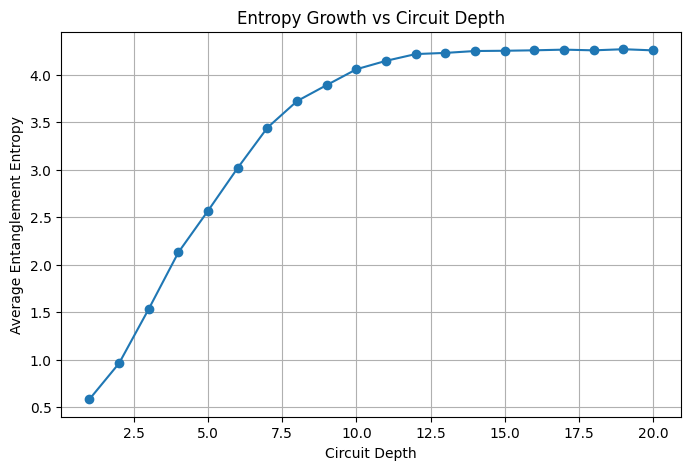

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_entropies,
    marker='o'
)

plt.xlabel("Circuit Depth")

plt.ylabel("Average Entanglement Entropy")

plt.title(
    "Entropy Growth vs Circuit Depth"
)

plt.grid(True)

plt.show()

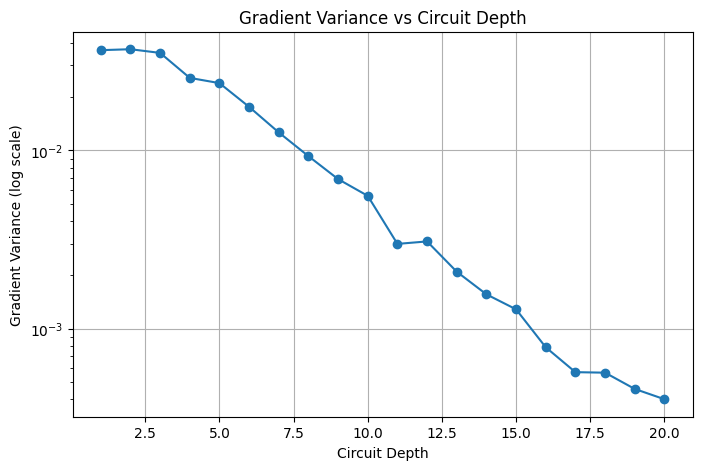

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_gradient_variances,
    marker='o'
)

plt.yscale("log")

plt.xlabel("Circuit Depth")

plt.ylabel(
    "Gradient Variance (log scale)"
)

plt.title(
    "Gradient Variance vs Circuit Depth"
)

plt.grid(True)

plt.show()

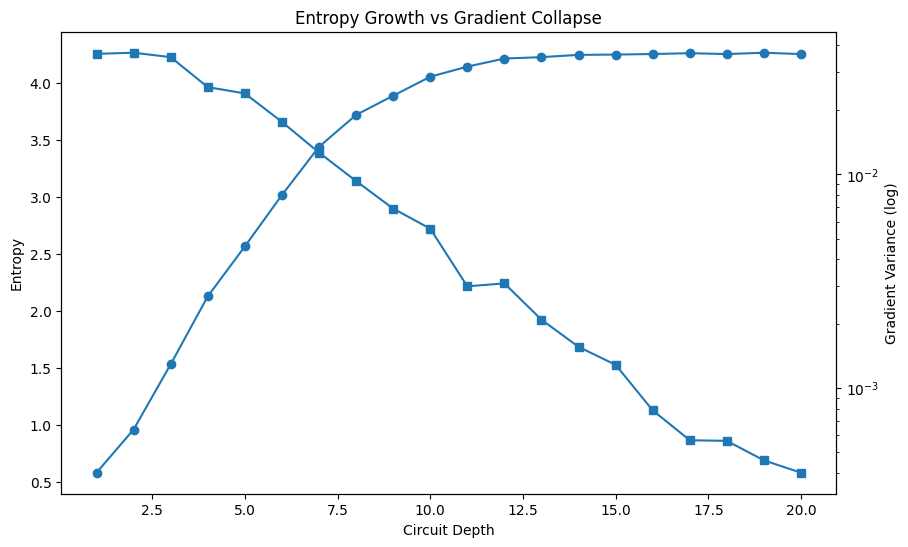

In [32]:
fig, ax1 = plt.subplots(
    figsize=(10,6)
)

ax1.plot(
    range(1, MAX_DEPTH+1),
    avg_entropies,
    marker='o',
    label='Entropy'
)

ax1.set_xlabel(
    "Circuit Depth"
)

ax1.set_ylabel(
    "Entropy"
)

ax2 = ax1.twinx()

ax2.plot(
    range(1, MAX_DEPTH+1),
    avg_gradient_variances,
    marker='s'
)

ax2.set_yscale("log")

ax2.set_ylabel(
    "Gradient Variance (log)"
)

plt.title(
    "Entropy Growth vs Gradient Collapse"
)

plt.show()

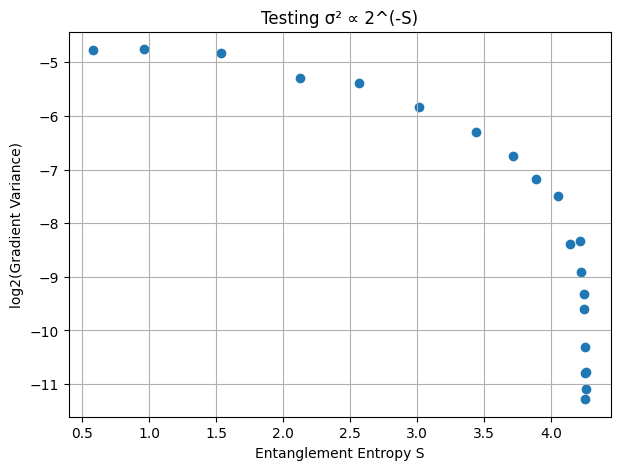

In [33]:
plt.figure(figsize=(7,5))
plt.scatter(avg_entropies, np.log2(avg_gradient_variances))
plt.xlabel("Entanglement Entropy S")
plt.ylabel("log2(Gradient Variance)")
plt.title("Testing σ² ∝ 2^(-S)")
plt.grid(True)
plt.show()

In [34]:
# ==========================================
# Sparse Entanglement Ansatz
#
# Same rotations as HEA
# BUT much fewer CNOT gates
#
# Goal:
# Slow information propagation
#
# ==========================================

def Sparse_HEA(params, depth):

    param_idx = 0

    for d in range(depth):

        # Rotation layer

        for qubit in range(N_QUBITS):

            qml.RY(
                params[param_idx],
                wires=qubit
            )

            param_idx += 1

        # Sparse entanglement

        qml.CNOT(wires=[0,1])
        qml.CNOT(wires=[2,3])
        qml.CNOT(wires=[4,5])

In [35]:
# ==========================================
# State circuit for sparse ansatz
# ==========================================

@qml.qnode(dev)
def sparse_state_circuit(params, depth):

    Sparse_HEA(params, depth)

    return qml.state()

In [36]:
# ==========================================
# Cost circuit for sparse ansatz
# ==========================================

@qml.qnode(dev)
def sparse_cost_circuit(params, depth):

    Sparse_HEA(params, depth)

    return qml.expval(qml.PauliZ(0))

In [37]:
# ==========================================
# Run same experiment
# ==========================================

sparse_entropies = []

sparse_gradient_variances = []

for depth in range(1, MAX_DEPTH + 1):

    depth_entropies = []

    depth_gradients = []

    print(f"Sparse Depth {depth}")

    for sample in range(N_SAMPLES):

        params = np.random.uniform(
            0,
            2*np.pi,
            size=depth * N_QUBITS,
            requires_grad=True
        )

        state = sparse_state_circuit(
            params,
            depth
        )

        entropy = bipartite_entropy(state)

        depth_entropies.append(entropy)

        grad_fn = qml.grad(
            sparse_cost_circuit
        )

        gradients = grad_fn(
            params,
            depth
        )

        depth_gradients.extend(
            np.abs(gradients)
        )

    sparse_entropies.append(
        np.mean(depth_entropies)
    )

    sparse_gradient_variances.append(
        np.var(depth_gradients)
    )

Sparse Depth 1
Sparse Depth 2
Sparse Depth 3
Sparse Depth 4
Sparse Depth 5
Sparse Depth 6
Sparse Depth 7
Sparse Depth 8
Sparse Depth 9
Sparse Depth 10
Sparse Depth 11
Sparse Depth 12
Sparse Depth 13
Sparse Depth 14
Sparse Depth 15
Sparse Depth 16
Sparse Depth 17
Sparse Depth 18
Sparse Depth 19
Sparse Depth 20


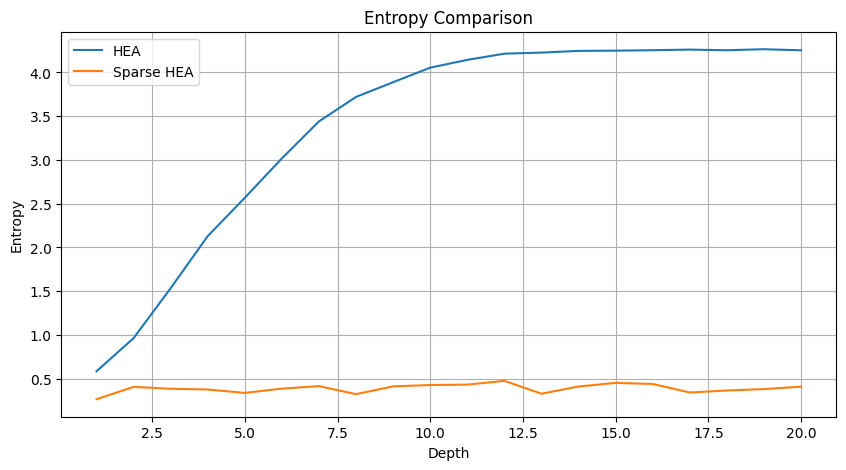

In [38]:
# ==========================================
# Compare Entropy
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_entropies,
    label="HEA"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    sparse_entropies,
    label="Sparse HEA"
)

plt.xlabel("Depth")
plt.ylabel("Entropy")
plt.title("Entropy Comparison")
plt.legend()
plt.grid(True)

plt.show()

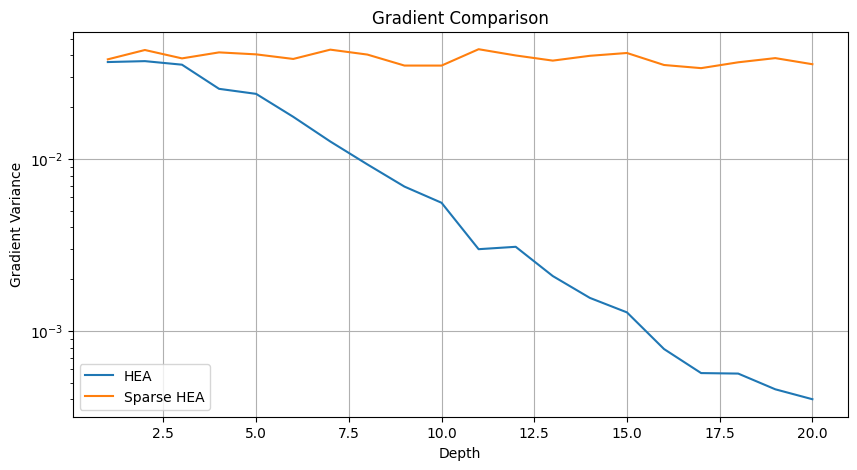

In [39]:
# ==========================================
# Compare Gradient Variance
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1, MAX_DEPTH+1),
    avg_gradient_variances,
    label="HEA"
)

plt.plot(
    range(1, MAX_DEPTH+1),
    sparse_gradient_variances,
    label="Sparse HEA"
)

plt.yscale("log")

plt.xlabel("Depth")
plt.ylabel("Gradient Variance")
plt.title("Gradient Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [40]:
# ==========================================
# Brick-Wall Ansatz
#
# Same rotations as HEA
# BUT entangling gates alternate between
# two disjoint patterns each layer:
#
# Even layers: (0,1) (2,3) (4,5)
# Odd  layers: (1,2) (3,4)
#
# This is a fully connected circuit
# (information eventually reaches every
# qubit), but spreads at a linear
# "light cone" rate of ~1 qubit per layer,
# instead of the full chain's near-instant
# spread within a single layer.
#
# ==========================================

def BrickWall_HEA(params, depth):

    param_idx = 0

    for d in range(depth):

        # Rotation layer
        for qubit in range(N_QUBITS):

            qml.RY(
                params[param_idx],
                wires=qubit
            )

            param_idx += 1

        # Alternating entangling pattern
        if d % 2 == 0:

            # Even layer: pairs (0,1), (2,3), (4,5)
            for q in range(0, N_QUBITS - 1, 2):
                qml.CNOT(wires=[q, q + 1])

        else:

            # Odd layer: pairs (1,2), (3,4)
            for q in range(1, N_QUBITS - 1, 2):
                qml.CNOT(wires=[q, q + 1])

In [41]:
# ==========================================
# State circuit for brick-wall ansatz
# ==========================================

@qml.qnode(dev)
def brickwall_state_circuit(params, depth):

    BrickWall_HEA(params, depth)

    return qml.state()


# ==========================================
# Cost circuit for brick-wall ansatz
# ==========================================

@qml.qnode(dev)
def brickwall_cost_circuit(params, depth):

    BrickWall_HEA(params, depth)

    return qml.expval(qml.PauliZ(0))

In [42]:
# ==========================================
# Run same experiment for brick-wall ansatz
# ==========================================

brickwall_entropies = []

brickwall_gradient_variances = []

for depth in range(1, MAX_DEPTH + 1):

    depth_entropies = []

    depth_gradients = []

    print(f"BrickWall Depth {depth}")

    for sample in range(N_SAMPLES):

        params = np.random.uniform(
            0,
            2*np.pi,
            size=depth * N_QUBITS,
            requires_grad=True
        )

        state = brickwall_state_circuit(
            params,
            depth
        )

        entropy = bipartite_entropy(state)

        depth_entropies.append(entropy)

        grad_fn = qml.grad(
            brickwall_cost_circuit
        )

        gradients = grad_fn(
            params,
            depth
        )

        depth_gradients.extend(
            np.abs(gradients)
        )

    brickwall_entropies.append(
        np.mean(depth_entropies)
    )

    brickwall_gradient_variances.append(
        np.var(depth_gradients)
    )

BrickWall Depth 1
BrickWall Depth 2
BrickWall Depth 3
BrickWall Depth 4
BrickWall Depth 5
BrickWall Depth 6
BrickWall Depth 7
BrickWall Depth 8
BrickWall Depth 9
BrickWall Depth 10
BrickWall Depth 11
BrickWall Depth 12
BrickWall Depth 13
BrickWall Depth 14
BrickWall Depth 15
BrickWall Depth 16
BrickWall Depth 17
BrickWall Depth 18
BrickWall Depth 19
BrickWall Depth 20


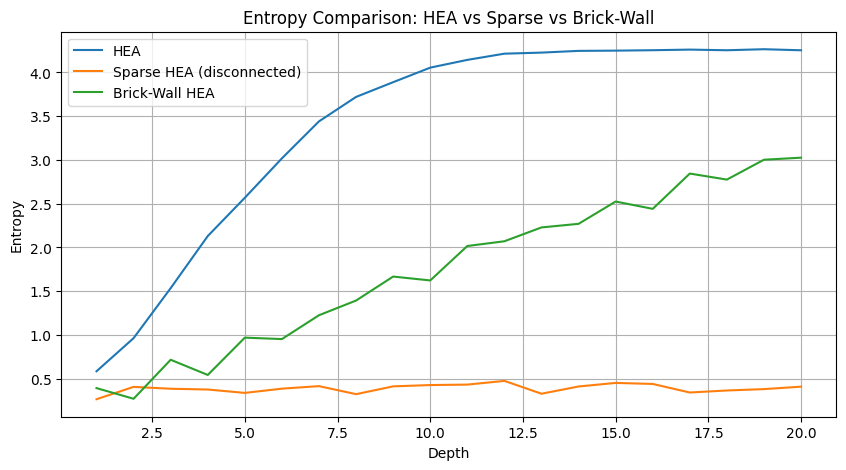

In [43]:
plt.figure(figsize=(10,5))

plt.plot(range(1, MAX_DEPTH+1), avg_entropies, label="HEA")
plt.plot(range(1, MAX_DEPTH+1), sparse_entropies, label="Sparse HEA (disconnected)")
plt.plot(range(1, MAX_DEPTH+1), brickwall_entropies, label="Brick-Wall HEA")

plt.xlabel("Depth")
plt.ylabel("Entropy")
plt.title("Entropy Comparison: HEA vs Sparse vs Brick-Wall")
plt.legend()
plt.grid(True)

plt.show()

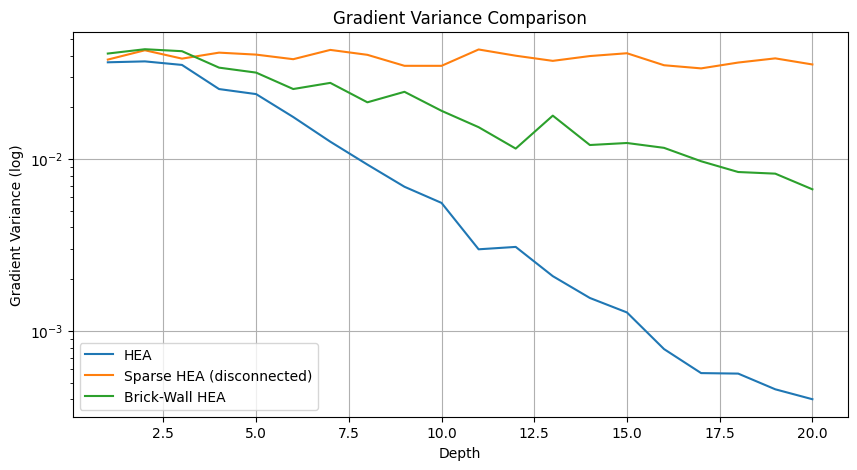

In [44]:
plt.figure(figsize=(10,5))

plt.plot(range(1, MAX_DEPTH+1), avg_gradient_variances, label="HEA")
plt.plot(range(1, MAX_DEPTH+1), sparse_gradient_variances, label="Sparse HEA (disconnected)")
plt.plot(range(1, MAX_DEPTH+1), brickwall_gradient_variances, label="Brick-Wall HEA")

plt.yscale("log")

plt.xlabel("Depth")
plt.ylabel("Gradient Variance (log)")
plt.title("Gradient Variance Comparison")
plt.legend()
plt.grid(True)

plt.show()